In [11]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


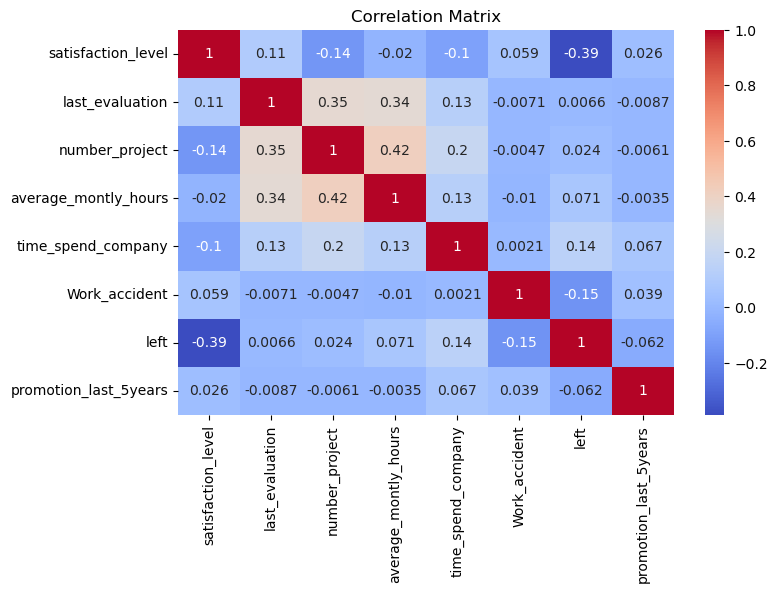

In [12]:
# Correlation with 'left'
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**2 SALARY VS EMPLOYEE RETENTION**

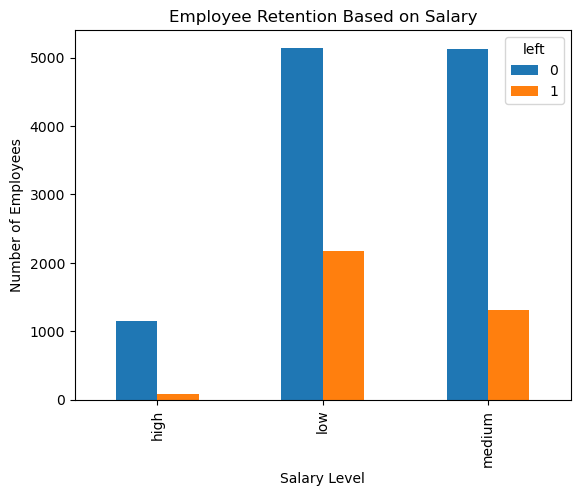

In [13]:
salary_retention = pd.crosstab(df.salary, df.left)

salary_retention.plot(kind='bar')
plt.title("Employee Retention Based on Salary")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.show()

**Logastic regeression**

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
X = pd.get_dummies(X, columns=['salary'])
y = df.left

In [15]:
#split dataset & tain model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [16]:
accuracy = model.score(X_test, y_test)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.762


In [17]:
coef = model.coef_[0]

intercept = model.intercept_[0]

In [18]:
# L sigmoid
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

In [19]:
#Manual LRP
def manual_prediction(input_row):
    z = intercept
    for i in range(len(coef)):
        z += coef[i] * input_row[i]
    return sigmoid(z)

In [20]:
#test manual LRP
sample = X.iloc[0].values
manual_prediction(sample)

0.42630819919850654